In [7]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [78]:

popt = (8.850746809616503, 3.1529653773260113e-08, 1.8431291583069498e-07, -3.045626636512152e-11, -1.2868670655791941e-11, -1.9932337140297774e-10,
        281.47469555461265, 5.444228284856578e-08, 3.605110140136869e-07, -4.134076192438302e-11, -3.38115917642573e-11, -3.8680819488579754e-10,
        68.54314494631173, 1.577073539815732e-08, 1.7067601663228738e-07, 8.356022677854765e-12, -4.187519891929968e-11, -1.7572968849459522e-10)



In [79]:
def fit_2D26_2(coords, *vars):
    """
    From niriss_specwcs code:
    https://grit.stsci.edu/NIRISS/reference-file-creation/specwcs/-/blob/main/niriss_specwcs/make_specwcs.py?ref_type=heads#L433
    """
    # Generalized 2D polynomial (2,n) order
    (x,y,t) = coords
    e = vars
    n = len(e)//6
    f = 0

    for i in range(n):
        f = f + t**i * (e[i*6] + x*e[i*6+1] + y*e[i*6+2] + x**2*e[i*6+3] + x*y*e[i*6+4] + y**2*e[i*6+5])
    return f

In [80]:
tracefile = "/Users/apetric/Desktop/LRS_WFSS/codes/trace_grid_output.txt"
df = pd.read_csv(tracefile, delimiter=" ")
x = df["X0"].values
y = df["Y0"].values
dx = df["dx"].values
dy = df["dy"].values
lam = df["lam"].values
# Filter the subset
subset = df[(df['X0'] == 450) & (df['Y0'] == 450)]
xpos = subset['X0'] + subset['dx']
print(len(xpos))

388


In [81]:
print(popt)
#dy_fit_subset = fit_2D26_2((x, y, dx), *popt)
dy_fitted = fit_2D26_2((subset["X0"], subset["Y0"], subset["dx"]), *popt)
#fit_2D26_2((subset["X0"], subset["Y0"], subset[), *popt)
print(len(dy_fitted))
print(dy_fitted)

(8.850746809616503, 3.1529653773260113e-08, 1.8431291583069498e-07, -3.045626636512152e-11, -1.2868670655791941e-11, -1.9932337140297774e-10, 281.47469555461265, 5.444228284856578e-08, 3.605110140136869e-07, -4.134076192438302e-11, -3.38115917642573e-11, -3.8680819488579754e-10, 68.54314494631173, 1.577073539815732e-08, 1.7067601663228738e-07, 8.356022677854765e-12, -4.187519891929968e-11, -1.7572968849459522e-10)
388
4656     65.825292
4657     65.494297
4658     65.157308
4659     64.813717
4660     64.463842
           ...    
5039   -274.377517
5040   -274.735512
5041   -275.082730
5042   -275.419168
5043   -275.744708
Length: 388, dtype: float64


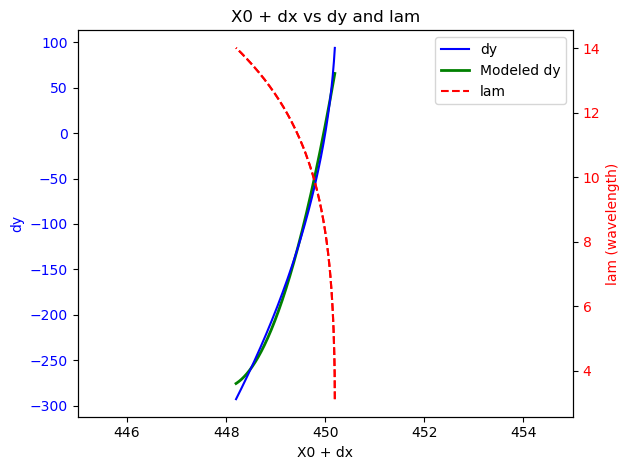

In [82]:

# Create the plot
fig, ax1 = plt.subplots()

# Plot dy and modeled dy on ax1
#line1, = ax1.plot(xpos + subset['dx'], subset['dy'], 'b-', label='dy')
line2, = ax1.plot(xpos, dy_fitted, color='green', linewidth=2, label="Modeled dy")

# Plot X0 vs dy on the first y-axis
ax1.plot(xpos, subset['dy'], 'b-', label='dy')
ax1.set_xlabel('X0 + dx')
ax1.set_ylabel('dy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlim(445, 455)

#ax1.plot(xpos, dy_fitted, label="Modeled dy", color='green', linewidth=2)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(xpos, subset['lam'], 'r--', label='lam')
line3, = ax2.plot(xpos, subset['lam'], 'r--', label='lam')
ax2.set_ylabel('lam (wavelength)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Combine legends from both axes
lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('X0 + dx vs dy and lam')
fig.tight_layout()
#plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(measured_dy, fitted_dy, s=5)
plt.xlabel("Measured dy")
plt.ylabel("Fitted dy")
plt.plot([measured_dy.min(), measured_dy.max()],
         [measured_dy.min(), measured_dy.max()], 'r--')
plt.title("Measured vs Fitted dy")

# Residuals
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=50)
plt.xlabel("Residual (measured - fitted)")
plt.title("Residuals")

plt.tight_layout()
plt.show()